In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler

df = pd.read_csv("/Users/Nico/Desktop/DS5110/Project/Code/PREPROCESSED_NO_MISSING_UKNOWN.csv")
df_cleaned = df.drop(columns=['Unnamed: 0','state_fips_code','county_fips_code'])
df_extracleaned = df_cleaned.drop(columns=['res_state','res_county','process','case_month','icu_yn','current_status','death_yn','case_positive_specimen_interval','case_onset_interval'])

X = df_extracleaned.drop(columns='hosp_yn')
y = df_extracleaned['hosp_yn']
cols = df.columns

le = LabelEncoder()
y_encoded = le.fit_transform(y)
X_dummies = pd.get_dummies(X,drop_first=True)

print(pd.unique(y_encoded))
X_dummies

[0 1]


,pre_test,age_group_18 to 49 years,age_group_50 to 64 years,age_group_65+ years,sex_Male,race_Asian,race_Black,race_Multiple/Other,race_Native Hawaiian/Other Pacific Islander,race_White,ethnicity_Non-Hispanic/Latino,underlying_conditions_yn_Yes
0,0,True,False,False,False,False,False,False,False,True,True,True
1,0,False,False,True,True,False,False,False,False,True,True,True
2,0,True,False,False,True,False,False,False,False,True,False,True
3,0,True,False,False,False,False,True,False,False,False,True,True
4,0,True,False,False,False,False,False,False,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...
53175,0,True,False,False,False,False,True,False,False,False,True,True
53176,1,False,False,True,True,False,False,False,False,True,True,True
53177,0,True,False,False,True,False,False,False,False,True,True,True
53178,0,True,False,False,False,False,True,False,False,False,True,True


In [41]:
from sklearn.model_selection import train_test_split, cross_val_score
X_train_val, X_test, y_train_val, y_test = train_test_split(X_dummies, y_encoded, test_size=0.2, random_state=42)
X_train_val

,pre_test,age_group_18 to 49 years,age_group_50 to 64 years,age_group_65+ years,sex_Male,race_Asian,race_Black,race_Multiple/Other,race_Native Hawaiian/Other Pacific Islander,race_White,ethnicity_Non-Hispanic/Latino,underlying_conditions_yn_Yes
46746,1,False,False,True,False,False,False,False,False,True,True,True
31252,1,True,False,False,False,False,True,False,False,False,True,True
6330,1,True,False,False,False,False,False,False,False,True,True,True
13670,0,False,True,False,False,False,True,False,False,False,True,True
8929,1,True,False,False,True,False,False,False,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...
11284,0,True,False,False,False,False,False,False,False,True,True,True
44732,0,False,False,True,True,False,False,False,False,True,True,True
38158,1,False,True,False,False,False,False,False,False,True,False,True
860,0,True,False,False,False,False,False,False,False,True,True,True


In [42]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV,KFold

params = {
    'max_depth': list(range(2,11)),
    'n_estimators': list(range(3,19)),
    'learning_rate': np.linspace(0.05,1.0,20)
}

cv = KFold(n_splits=4,shuffle=True,random_state=42)
grid_search = GridSearchCV(
    estimator = XGBClassifier(random_state = 42),
    param_grid = params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
)

grid_search.fit(X_train_val, y_train_val)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': array([0.05, ..., 0.95, 1. ]), 'max_depth': [2, 3, ...], 'n_estimators': [3, 4, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate i

In [43]:
import pandas as pd
results = pd.DataFrame(grid_search.cv_results_)
cols = [
    'param_n_estimators',
    'param_max_depth',
    'mean_test_score',
    'std_test_score',
    'rank_test_score',
    'mean_fit_time'
]
results.sort_values('rank_test_score').head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_max_depth,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
1619,0.028252,0.001686,0.003638,0.001286,0.60,4,6,"{'learning_rate': 0.6, 'max_depth': 4, 'n_esti...",0.780115,0.779175,0.77988,0.777882,0.783263,0.780063,0.001779,1
2352,0.030289,0.003095,0.003706,0.000903,0.85,5,3,"{'learning_rate': 0.85, 'max_depth': 5, 'n_est...",0.780115,0.779175,0.77988,0.777882,0.783263,0.780063,0.001779,1
1334,0.034117,0.002720,0.003593,0.000198,0.50,4,9,"{'learning_rate': 0.49999999999999994, 'max_de...",0.779998,0.779175,0.77988,0.777882,0.783263,0.780040,0.001779,3
1335,0.034322,0.001794,0.003317,0.000112,0.50,4,10,"{'learning_rate': 0.49999999999999994, 'max_de...",0.779998,0.779175,0.77988,0.777882,0.783263,0.780040,0.001779,3
2040,0.051499,0.017032,0.004329,0.000786,0.75,3,11,"{'learning_rate': 0.75, 'max_depth': 3, 'n_est...",0.779998,0.779175,0.77988,0.777882,0.783263,0.780040,0.001779,3
2041,0.039485,0.006584,0.004574,0.001406,0.75,3,12,"{'learning_rate': 0.75, 'max_depth': 3, 'n_est...",0.779998,0.779175,0.77988,0.777882,0.783263,0.780040,0.001779,3
2042,0.040259,0.001964,0.003942,0.000817,0.75,3,13,"{'learning_rate': 0.75, 'max_depth': 3, 'n_est...",0.779998,0.779175,0.77988,0.777882,0.783263,0.780040,0.001779,3
2043,0.042073,0.003406,0.005871,0.003476,0.75,3,14,"{'learning_rate': 0.75, 'max_depth': 3, 'n_est...",0.779998,0.779175,0.77988,0.777882,0.783263,0.780040,0.001779,3
1778,0.046754,0.008357,0.004358,0.000939,0.65,5,5,"{'learning_rate': 0.65, 'max_depth': 5, 'n_est...",0.779998,0.779175,0.77988,0.777882,0.783263,0.780040,0.001779,3
621,0.041305,0.001475,0.004570,0.001117,0.25,4,16,"{'learning_rate': 0.25, 'max_depth': 4, 'n_est...",0.779998,0.779175,0.77988,0.777882,0.783263,0.780040,0.001779,3


Accuracy: 0.775667544189545

Classification Report:
              precision    recall  f1-score   support

          No       0.78      0.98      0.87      8230
         Yes       0.53      0.08      0.14      2406

    accuracy                           0.78     10636
   macro avg       0.66      0.53      0.50     10636
weighted avg       0.73      0.78      0.71     10636


Confusion Matrix:
Sensitivity: 0.07896924355777224 
Specificity/Recall: 0.9793438639125152 
Precision 0.5277777777777778


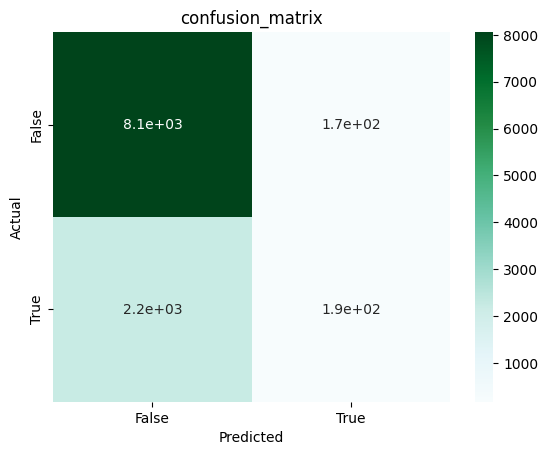

In [44]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred = grid_search.best_estimator_.predict(X_test)

print("Accuracy:", grid_search.best_estimator_.score(X_test, y_test))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))
print("\nConfusion Matrix:")

plt.figure()
# cmap = sns.color_palette(['#CAD733','#00BF00','#077187','#054ED9','#074F57','#EF3E36','#C056A5'], as_cmap=True)
cmap = sns.color_palette('BuGn', as_cmap=True)
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap=cmap)
plt.title('confusion_matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0.5,1.5],["False","True"])
plt.yticks([0.5,1.5],["False","True"])

conf = confusion_matrix(y_test,y_pred)
tn = conf[0,0]
fn = conf[1,0]
fp = conf[0,1]
tp = conf[1,1]

sensitivity = tp/(tp+fn)
specificity = tn/(tn+fp)
precision = tp/(tp+fp)
print('Sensitivity:',sensitivity,'\nSpecificity/Recall:',specificity,'\nPrecision',precision)


                                    Feature  Importance
                        age_group_65+ years    0.619127
                   age_group_50 to 64 years    0.180449
                                   pre_test    0.056404
race_Native Hawaiian/Other Pacific Islander    0.032506
                                 race_Black    0.025681
                                 race_White    0.023554
                   age_group_18 to 49 years    0.018950
                                   sex_Male    0.018932
              ethnicity_Non-Hispanic/Latino    0.012045
                                 race_Asian    0.004924
               underlying_conditions_yn_Yes    0.003863
                        race_Multiple/Other    0.003566


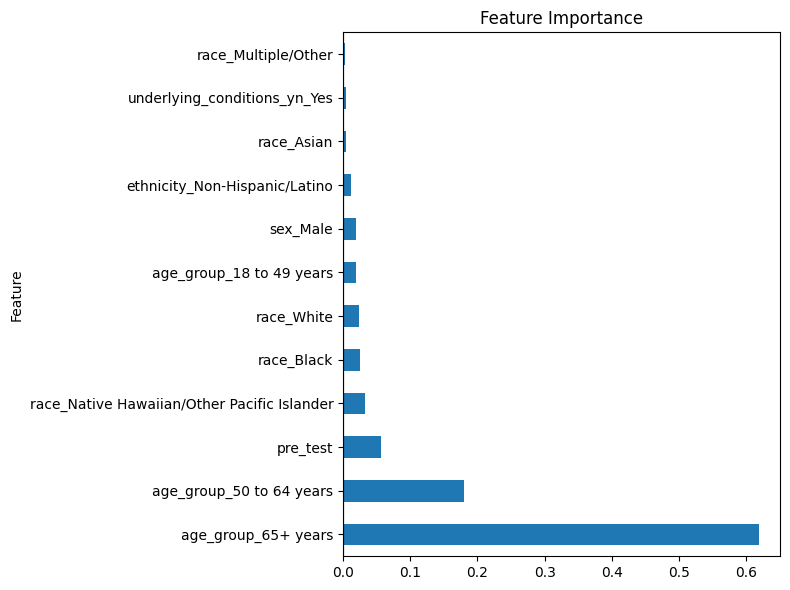

In [45]:
coef_df = pd.DataFrame({
    'Feature': X_dummies.columns,
    'Importance': grid_search.best_estimator_.feature_importances_
}).sort_values('Importance', ascending=False)

print(coef_df.to_string(index=False))

# Feature coefficients plot
coef_df.plot(kind='barh', x='Feature', y='Importance', figsize=(8, 6), legend=False)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

Note: Claude AI was used to support the postprocessing of the model after fitting the model to the data